<a href="https://colab.research.google.com/github/Aanshik-04/magic-scikit/blob/main/Magic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
colNames = ["flength", "fwidth", "fsize", "fConc", "fConc1", "fAsym", "fM3long", "fM3Trans", "fM3Alpha", "fDist", "class"]
df = pd.read_csv("magic04.data", names = colNames)
df.head()

,flength,fwidth,fsize,fConc,fConc1,fAsym,fM3long,fM3Trans,fM3Alpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [ ]:
df["class"] = (df["class"] == "g").astype(int)
df[df["class"] == 1]

,flength,fwidth,fsize,fConc,fConc1,fAsym,fM3long,fM3Trans,fM3Alpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1
...,...,...,...,...,...,...,...,...,...,...,...
12327,12.8703,11.4444,2.3811,0.7360,0.3805,-15.0946,5.3032,11.6208,21.0120,204.0370,1
12328,26.8595,20.5946,2.8754,0.3438,0.2152,-3.4556,-20.0014,-9.0535,3.9848,205.4980,1
12329,22.0913,10.8949,2.2945,0.5381,0.2919,15.2776,18.2296,7.3975,21.0680,123.2810,1
12330,56.2216,18.7019,2.9297,0.2516,0.1393,96.5758,-41.2969,11.3764,5.9110,197.2090,1


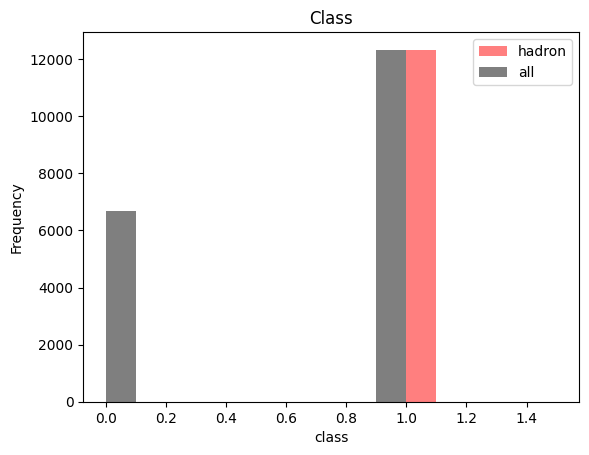

In [ ]:
plt.hist(df[df["class"] == 1]["class"], color="red", alpha=0.5, label="hadron")
# plt.show()
# plt.hist(df[df["class"] == 0]["class"], color="blue", alpha=0.5, label="alpha")
plt.hist(df["class"], color="black", alpha=0.5, label="all")
plt.xlabel("class")
plt.ylabel("Frequency")
plt.title("Class")
plt.legend()

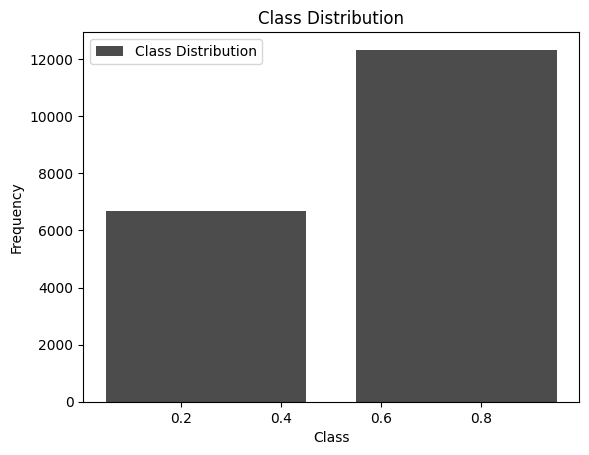

In [ ]:
plt.hist(df["class"], bins=2, color="black", alpha=0.7, rwidth=0.8, label="Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Class Distribution")
plt.legend()
plt.show()

#Training, validation and testing of dataset


In [ ]:
# split the dataset as 60:20:20
train, validate, test = np.split(df.sample(frac=1), [int(0.6 * len(df)), int(0.8 * len(df))])
    # df.sample(frac=1) basically returns a randomised sample of the dataframe and if frac=1 whole dataframe is returned in shuffled order.

# preprocess the dataset - scaling
def scale_dataFrame(dataFrame, overSample=False):
  features, values = dataFrame[dataFrame.columns[:-1]].values, dataFrame[dataFrame.columns[-1]].values
  scaler = StandardScaler()
  features = scaler.fit_transform(features)

  if overSample:
    ros = RandomOverSampler()
    features, values = ros.fit_resample(features, values)

  data = np.hstack((features, np.reshape(values, (-1, 1))))

  return data, features, values


/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
train_data, train_features, train_values = scale_dataFrame(train, overSample=True)
validation_data, validation_features, validation_values = scale_dataFrame(validate)
test_data, test_features, test_values = scale_dataFrame(test)

# K Nearest Neighbors (kNN)

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=2)
knn_model = knn_model.fit(train_features, train_values)
knn_predictions = knn_model.predict(test_features)
print(classification_report(test_values, knn_predictions))

              precision    recall  f1-score   support

           0       0.67      0.78      0.72      1350
           1       0.87      0.79      0.83      2454

    accuracy                           0.79      3804
   macro avg       0.77      0.79      0.78      3804
weighted avg       0.80      0.79      0.79      3804



# Naive Baye's model (Gaussian Naive Baye's)

In [ ]:
nb_model = GaussianNB()
nb_model = nb_model.fit(train_features, train_values)
nb_predictions = nb_model.predict(test_features)
print(classification_report(test_values, nb_predictions))

              precision    recall  f1-score   support

           0       0.67      0.39      0.49      1350
           1       0.73      0.89      0.80      2454

    accuracy                           0.72      3804
   macro avg       0.70      0.64      0.65      3804
weighted avg       0.71      0.72      0.69      3804



# Logistic Regression

In [ ]:
lr_model = LogisticRegression()
lr_model = lr_model.fit(train_features, train_values)
lr_predictions = lr_model.predict(test_features)
print(classification_report(test_values, lr_predictions))

              precision    recall  f1-score   support

           0       0.69      0.73      0.71      1350
           1       0.85      0.82      0.83      2454

    accuracy                           0.79      3804
   macro avg       0.77      0.77      0.77      3804
weighted avg       0.79      0.79      0.79      3804



# Support Vector Machine(svm) - Support Vector Classification(SVC)

In [ ]:
svm_model = SVC()
svm_model = svm_model.fit(train_features, train_values)
svm_predictions = svm_model.predict(test_features)
print(classification_report(test_values, svm_predictions))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1350
           1       0.89      0.90      0.90      2454

    accuracy                           0.86      3804
   macro avg       0.85      0.85      0.85      3804
weighted avg       0.86      0.86      0.86      3804



# Neural Networks

In [ ]:
def plot_accuracy(history):
  plt.plot(history.history['accuracy'], label="accuracy")
  plt.plot(history.history['val_accuracy'], label='validation accuracy')
  plt.legend()
  plt.xlabel('epochs')
  plt.ylabel('accuracy')
  plt.show()

In [ ]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation loss')
  plt.legend()
  plt.xlabel("epochs")
  plt.ylabel("loss")
  plt.show()

In [ ]:
import tensorflow as tf

In [ ]:
nn_model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=(10,)), # here 10 signifies that each sample has 10 input features (else it raises error)
  tf.keras.layers.Dense(64, activation='relu'), # relu = rectified linear unit (ReLU(x) = max(0, x))
  # Dropout(0.3) # used to prevent overfitting
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = nn_model.fit(train_features, train_values, validation_split=0.2, batch_size=32, epochs=100, verbose=None)

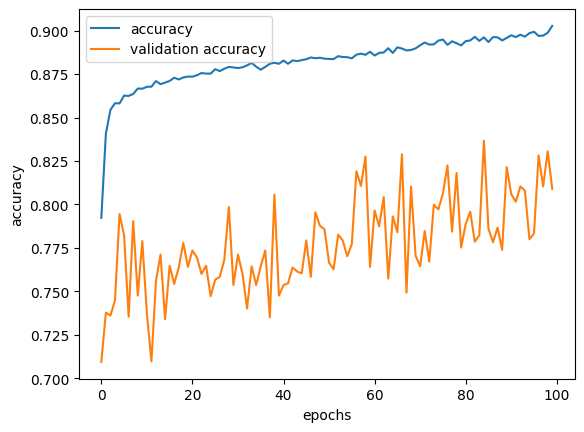

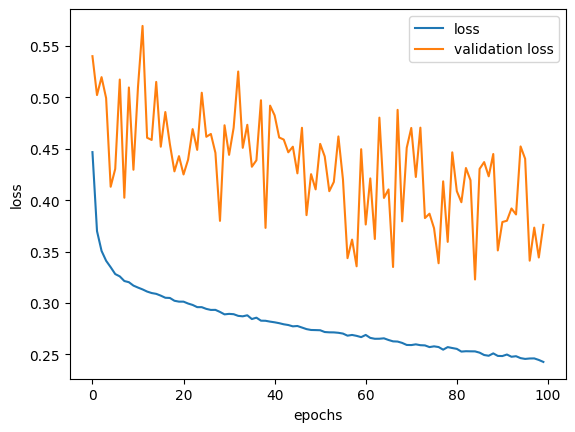

In [ ]:
plot_accuracy(history)
plot_loss(history)